<a href="https://colab.research.google.com/github/doggie1126/orderPDF2excel/blob/main/%E6%8E%A1%E8%B3%BC%E5%96%AEpdf%E8%BD%89excel%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get update
!apt-get install -y poppler-utils

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,812 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.5 MB]
Hit:13 https://ppa.launchpadcontent.net/graphics-dri

In [ ]:
# 改成安裝 2.6.2 版本
!pip install paddlepaddle==2.6.2 paddleocr==2.8.1 pdf2image opencv-python pandas openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of tifffile to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 407.5/407.5 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.2 MB/s e

In [ ]:
# import numpy as np
# import cv2
# from pdf2image import convert_from_path
# from paddleocr import PaddleOCR
# from google.colab import files

# # 1. 上傳檔案 (自動抓取檔名)
# print("請上傳你的 PDF 檔案：")
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]

# # 2. PDF 轉圖片
# print(f"正在處理檔案: {filename}...")
# # ✅ 只讀取第 1 頁到第 1 頁
# pages = convert_from_path(filename, dpi=300, first_page=1, last_page=1)
# img_np = np.array(pages[0]) # 轉成 numpy array 供後續 OpenCV 處理

# # 3. 初始化 PaddleOCR
# # lang='ch' 會同時支援中文與英文/數字，use_angle_cls=True 會自動轉正微歪的掃描檔
# ocr = PaddleOCR(use_angle_cls=True, lang='ch')

# # 4. 進行全頁 OCR 辨識 (抓出所有文字與座標)
# print("開始掃描文字與座標...")
# result = ocr.ocr(img_np)

# # 5. 尋找關鍵欄位的中心點 X 座標 (這就是我們的基準線)
# target_columns = ["數量", "單價", "總金額", "交貨日期"] # 你可以根據實際表頭修改
# anchors = {}
# header_y = 0 # 記錄表頭的 Y 座標高度

# # 拆解 PaddleOCR 的輸出結構
# for idx in range(len(result[0])):
#     res = result[0][idx]
#     box = res[0]      # 座標四邊形 [[x1,y1], [x2,y2], [x3,y3], [x4,y4]]
#     text = res[1][0]  # 辨識出的文字內容

#     # 計算這個文字區塊的中心點 X 座標
#     center_x = (box[0][0] + box[1][0]) / 2

#     # 檢查是不是我們要找的表頭欄位
#     for col in target_columns:
#         if col in text:
#             anchors[col] = center_x
#             header_y = box[0][1] # 記錄表頭的高度位置
#             print(f"✅ 找到 [{col}] 欄位，基準 X 座標為: {center_x:.1f}")

# print("-" * 30)
# print("準備就緒！接下來可以使用這些 X 座標來垂直切割資料了。")

In [ ]:
# print("🔍 正在分析表頭區塊的原始 OCR 結果...\n")

# # 我們假設表頭大約在圖片的上半部 (Y 座標小於 1000 像素的位置)
# # 如果你的表頭比較下面，可以把 1000 改大一點
# for res in result[0]:
#     box = res[0]
#     text = res[1][0]

#     # 取得這個文字塊的左上角 Y 座標
#     y_pos = box[0][1]

#     # 只印出上半部的文字，避免印出太多下面密密麻麻的資料
#     if y_pos < 1000:
#         # 印出：[Y座標] 文字內容 (X座標)
#         center_x = (box[0][0] + box[1][0]) / 2
#         print(f"Y: {y_pos:4.0f} | X: {center_x:6.1f} | 辨識文字: '{text}'")

# print("\n------------------------------")
# print("請觀察上面的輸出，看看「單價」和「總金額」實際上被辨識成了什麼字串？")

In [ ]:
# @title
# print("開始掃描文字與座標並套用容錯字典...\n")

# # 1. 容錯字典
# column_mapping = {
#     "料號": "料號", "料号": "料號",
#     "單價": "單價", "罩價": "單價",
#     "總金額": "總金額", "總金额": "總金額",
#     "交貨日期": "交貨日期",
#     "工單": "工單", "工早": "工單", "工單號碼": "工單"
# }

# # 2. 理想版型的標準 X 座標 (用來計算欄位之間的「相對距離」)
# # (這裡的數字需要你根據圖片大約填一下)
# ideal_template_x = {
#     "料號": 400.0,
#     "單價": 1430.0,
#     "總金額": 1718.0,
#     "交貨日期": 1914.0,
#     "工單": 1876.0
# }

# anchors = {}
# header_y = 0

# # --- (執行 PaddleOCR 辨識與比對) ---
# if result is not None and len(result) > 0 and result[0] is not None:
#     for res in result[0]:
#         box = res[0]
#         text = res[1][0]
#         center_x = (box[0][0] + box[1][0]) / 2

#         for ocr_typo, real_col_name in column_mapping.items():
#             if ocr_typo in text:
#                 if real_col_name not in anchors:
#                     anchors[real_col_name] = center_x
#                     header_y = max(header_y, box[0][1])
#                     print(f"✅ 成功實體定位 [{real_col_name}] (原始: '{text}'), X 座標: {center_x:.1f}")

# print("\n--- 開始執行【相對位置】推論機制 ---")

# # 3. 找出還沒被抓到的欄位
# missing_columns = [col for col in ideal_template_x if col not in anchors]

# if len(anchors) == 0:
#     print("❌ 災難狀態：沒有抓到任何一個基準欄位，無法進行相對推論。")
# else:
#     for missing_col in missing_columns:
#         # 尋找距離這個遺失欄位「最近的」已辨識欄位
#         closest_found_col = None
#         min_distance = float('inf')

#         for found_col in anchors:
#             if found_col in ideal_template_x:
#                 # 計算在理想範本中，這兩個欄位的距離
#                 dist = abs(ideal_template_x[found_col] - ideal_template_x[missing_col])
#                 if dist < min_distance:
#                     min_distance = dist
#                     closest_found_col = found_col

#         # 算出身邊最近鄰居後，計算相對偏移量並推論
#         if closest_found_col:
#             # 相對距離 = 遺失欄位理想X - 鄰居理想X (有正有負，代表在右邊或左邊)
#             relative_offset = ideal_template_x[missing_col] - ideal_template_x[closest_found_col]

#             # 實際推論X = 鄰居的實際X + 相對距離
#             inferred_x = anchors[closest_found_col] + relative_offset
#             anchors[missing_col] = inferred_x

#             print(f"⚠️ 救援 [{missing_col}] 欄位：")
#             print(f"   -> 依靠最近鄰居 [{closest_found_col}] (座標 {anchors[closest_found_col]:.1f})")
#             print(f"   -> 加上相對距離 ({relative_offset:+.1f}) = 推論座標 {inferred_x:.1f}")

# print("\n------------------------------")
# print("🎯 最終完整的欄位座標字典：", anchors)

In [ ]:
# @title
import numpy as np
import cv2
from pdf2image import convert_from_path
from paddleocr import PaddleOCR
from google.colab import files
import pandas as pd
import re

# 1. 上傳 PDF
print("請上傳你的 PDF 檔案：")
uploaded = files.upload()

請上傳你的 PDF 檔案：


Saving 7000007134 京華(1).pdf to 7000007134 京華(1).pdf


In [ ]:
# @title

filename = list(uploaded.keys())[0]

# 初始化 OCR
ocr = PaddleOCR(use_angle_cls=True, lang='ch')

# 2. 定義完整的處理邏輯函數 (包含資料萃取與錯字容錯)
def process_page(img_np, header_y, anchors, procurement_no, factory_site):
    data_blocks = []
    data_start_y = header_y + 85

    result = ocr.ocr(img_np)
    if not result or not result[0]: return []

    # 欄位映射與容錯字典
    column_mapping = {
        "料號": "料號", "料号": "料號",
        "單價": "單價", "罩價": "單價",
        "總金額": "總金額", "總金额": "總金額",
        "交貨日期": "交貨日期",
        "工單": "工單", "工早": "工單", "工單號碼": "工單"
    }

    # 提取文字區塊
    for res in result[0]:
        box = res[0]
        text = res[1][0]
        center_x = (box[0][0] + box[1][0]) / 2
        center_y = (box[0][1] + box[2][1]) / 2

        # 只在「靠近表頭」的區域內做 Mapping，不要整張紙都掃
        if center_y < (header_y + 50):
            for typo, col in column_mapping.items():
                if typo == text.strip():
                    # 【核心修正】：只有當該欄位目前還沒有被定位，或者新抓到的位置更精準時才更新
                    # 我們這裡限制：如果已經有 anchors 了，就不再隨意覆蓋，避免抓到雜訊
                    if col not in anchors:
                        anchors[col] = center_x
                        print(f"✅ 成功定位 [{col}] 於 X={center_x:.1f}")

        if center_y > data_start_y:
            data_blocks.append({"text": text, "cx": center_x, "cy": center_y, "column": ""})


    # 【保險推論機制】：如果料號沒抓到，用其他已抓到的錨點推算
    ideal_template_x = {"品名": 400.0, "單價": 1430.0, "總金額": 1718.0, "交貨日期": 1914.0, "工單": 1876.0}

    for col in ideal_template_x:
        if col not in anchors:
            # 找距離最近且已存在的錨點
            found_anchors = [a for a in anchors if a in ideal_template_x]
            if found_anchors:
                # 找最靠近目標缺失欄位的那個鄰居
                neighbor = min(found_anchors, key=lambda a: abs(ideal_template_x[a] - ideal_template_x[col]))
                # 推算位置：鄰居實際 X + (目標理想 X - 鄰居理想 X)
                anchors[col] = anchors[neighbor] + (ideal_template_x[col] - ideal_template_x[neighbor])
                print(f"⚠️ 啟動安全機制：從 {neighbor} 推論出 {col} 位置為 {anchors[col]:.1f}")

    # 分配欄位
    for block in data_blocks:
        closest_col = min(anchors.keys(), key=lambda col: abs(anchors[col] - block['cx']))
        if abs(anchors[closest_col] - block['cx']) <= 180:
            block['column'] = closest_col

    # 分組行 (Y軸容忍度 20)
    data_blocks.sort(key=lambda x: x['cy'])
    lines = []
    current_line = []
    current_line_y = None
    for block in data_blocks:
        if current_line_y is None or abs(block['cy'] - current_line_y) < 20:
            current_line.append(block)
            current_line_y = block['cy']
        else:
            lines.append(current_line)
            current_line = [block]
            current_line_y = block['cy']
    lines.append(current_line)

    # 萃取資料
    final_data = []
    current_item = {"年": "", "月": "", "日": "", "工單": "", "料號": ""}
    for line in lines:
        line_text = " ".join([b['text'] for b in line])
        has_date = re.search(r'(\d{4})/(\d{1,2})/(\d{1,2})', line_text)
        has_seq = any(b['column'] == '料號' and re.match(r'^\d{4,5}$', b['text'].strip()) for b in line)

        if has_date or has_seq:
            if current_item["年"] or current_item["料號"]:
                final_data.append(current_item.copy())
                current_item = {"年": "", "月": "", "日": "", "工單": "", "料號": ""}
        if has_date:
            current_item["年"], current_item["月"], current_item["日"] = has_date.groups()
        wo_match = re.search(r'\d{8,}', line_text)
        if wo_match:
            current_item["工單"] = wo_match.group(0)
        for b in line:
            if b['column'] == '品名':
                text_clean = b['text'].strip()
                if not re.match(r'^\d{4,5}$', text_clean) and "備" not in text_clean:
                    if not current_item["料號"]: current_item["料號"] = text_clean
    if current_item["年"] or current_item["料號"] or current_item["工單"]:
        final_data.append(current_item)
    return final_data

# 3. 處理第一頁以取得全域資訊
pages = convert_from_path(filename, dpi=300)
first_img = np.array(pages[0])
first_result = ocr.ocr(first_img)[0]

# 定位錨點與採購單號
anchors = {}
header_y = 0
procurement_no = ""
factory_site = "未知"

for res in first_result:
    box = res[0]
    text = res[1][0]
    center_x = (box[0][0] + box[1][0]) / 2
    # 抓單號
    match = re.search(r'(\d{8,}-[CH])', text)
    if match and box[0][1] < 300: # Y < 300 的區域
        procurement_no = match.group(1)
        factory_site = "嘉義" if procurement_no.endswith('-C') else "新竹"
    # 抓表頭
    for typo, col in {"品名":"品名","單價":"單價","總金額":"總金額","交貨日期":"交貨日期","工單":"工單"}.items():
        if typo in text:
            anchors[col] = center_x
            header_y = max(header_y, box[0][1])

# 4. 主迴圈：處理所有頁面
total_all_data = []
for i, page in enumerate(pages):
    print(f"正在處理第 {i+1} 頁...")
    page_data = process_page(np.array(page), header_y, anchors, procurement_no, factory_site)
    for row in page_data:
        row.update({"廠區": factory_site, "採購單號": procurement_no})
        total_all_data.append(row)

# 5. 輸出
df_final = pd.DataFrame(total_all_data, columns=["年", "月", "日", "廠區", "採購單號", "工單", "料號"])
df_final.to_excel("Final_Complete_Report.xlsx", index=False)
files.download("Final_Complete_Report.xlsx")
print("✅ 處理完成！")

download https://paddleocr.bj.bcebos.com/PP-OCRv4/chinese/ch_PP-OCRv4_det_infer.tar to /root/.paddleocr/whl/det/ch/ch_PP-OCRv4_det_infer/ch_PP-OCRv4_det_infer.tar


100%|██████████| 4.89M/4.89M [00:22<00:00, 221kiB/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/chinese/ch_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/ch/ch_PP-OCRv4_rec_infer/ch_PP-OCRv4_rec_infer.tar


100%|██████████| 11.0M/11.0M [00:02<00:00, 4.10MiB/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


...

[2026/07/09 01:09:45] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/ch/ch_PP-OCRv4_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/ch/ch_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_c

[2026/07/09 01:09:47] ppocr DEBUG: dt_boxes num : 108, elapsed : 0.6933484077453613
[2026/07/09 01:09:48] ppocr DEBUG: cls num  : 108, elapsed : 0.5000576972961426
[2026/07/09 01:09:51] ppocr DEBUG: rec_res num  : 108, elapsed : 3.606937885284424
正在處理第 1 頁...
[2026/07/09 01:09:52] ppocr DEBUG: dt_boxes num : 108, elapsed : 0.2736034393310547
[2026/07/09 01:09:52] ppocr DEBUG: cls num  : 108, elapsed : 0.2377781867980957
[2026/07/09 01:09:56] ppocr DEBUG: rec_res num  : 108, elapsed : 3.909661054611206
✅ 成功定位 [單價] 於 X=1427.5
✅ 成功定位 [總金額] 於 X=1715.0
正在處理第 2 頁...
[2026/07/09 01:09:56] ppocr DEBUG: dt_boxes num : 58, elapsed : 0.3379781246185303
[2026/07/09 01:09:57] ppocr DEBUG: cls num  : 58, elapsed : 0.17705488204956055
[2026/07/09 01:10:00] ppocr DEBUG: rec_res num  : 58, elapsed : 3.777271032333374


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 處理完成！


🎨 正在繪製座標驗證圖...



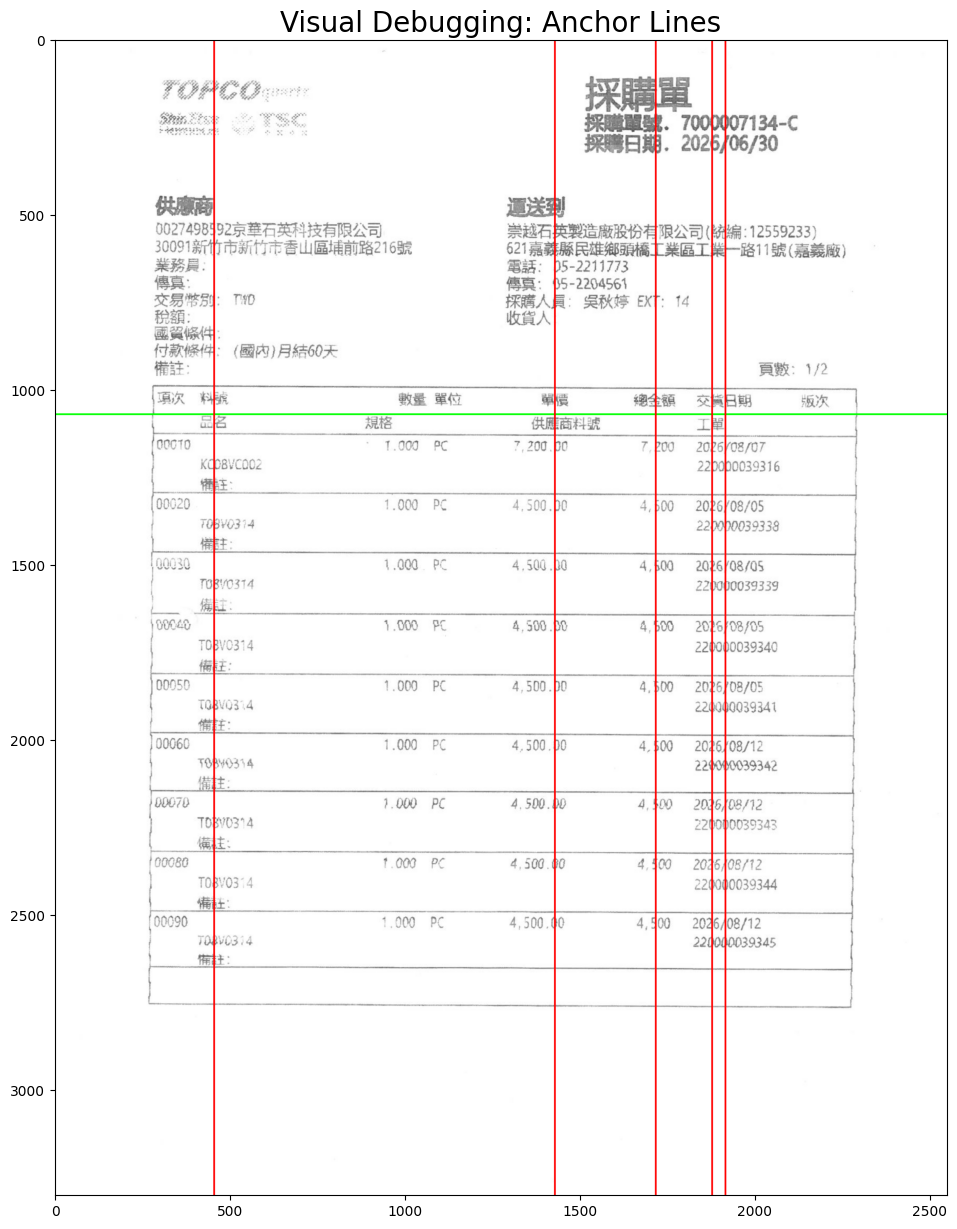

In [ ]:
import cv2
import matplotlib.pyplot as plt

print("🎨 正在繪製座標驗證圖...\n")

# 複製原圖，以免把線畫在原本的陣列上影響其他操作
current_page_img = np.array(pages[0])
vis_img = current_page_img.copy()

# 1. 畫出表頭的水平基準線 (綠線)
# 標示出哪裡是「表頭」，哪裡是「資料區」的分界
start_y = int(header_y)
cv2.line(vis_img, (0, start_y), (vis_img.shape[1], start_y), (0, 255, 0), 4)

# 2. 畫出每個欄位的垂直對齊線 (紅線)
for col, x in anchors.items():
    x_pos = int(x)
    # 從圖片最上方 (y=0) 畫到最下方 (y=高度)
    cv2.line(vis_img, (x_pos, 0), (x_pos, vis_img.shape[0]), (255, 0, 0), 4)

# 3. 使用 matplotlib 在 Colab 顯示大圖
plt.figure(figsize=(25, 15)) # 數字越大，顯示的圖片越大，方便肉眼看細節
plt.imshow(vis_img)
plt.title("Visual Debugging: Anchor Lines", fontsize=20)
#plt.axis('off') # 隱藏圖表邊緣的數字坐標軸
plt.show()